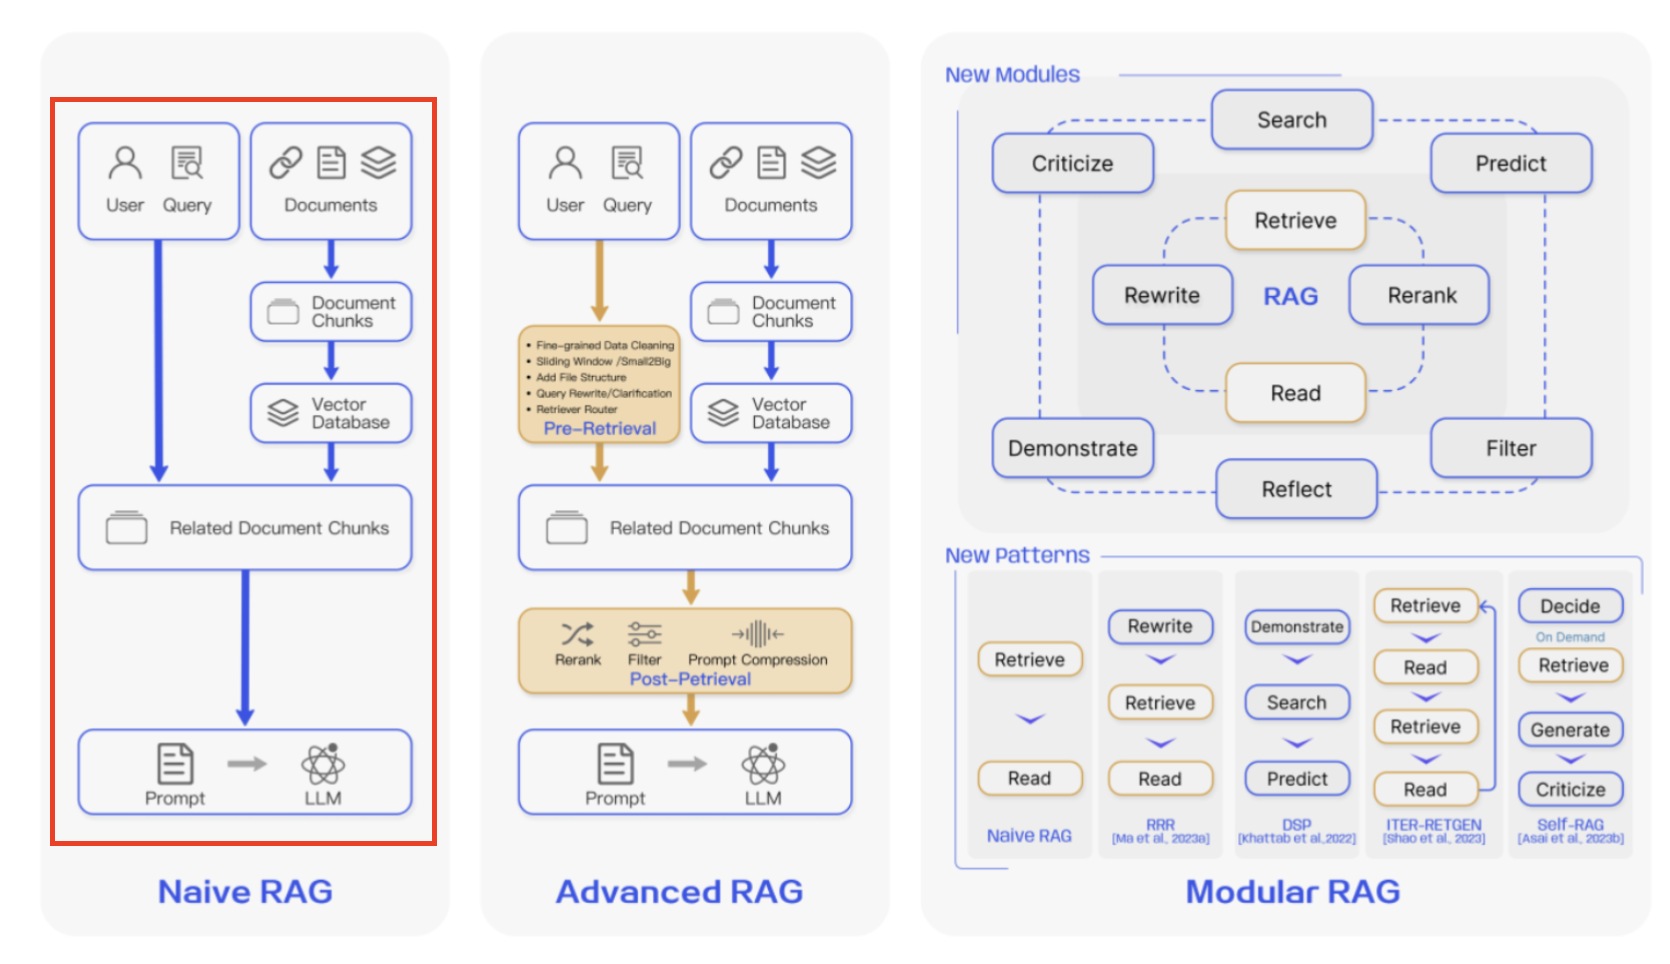

# Naive RAG with LangChain LCEL


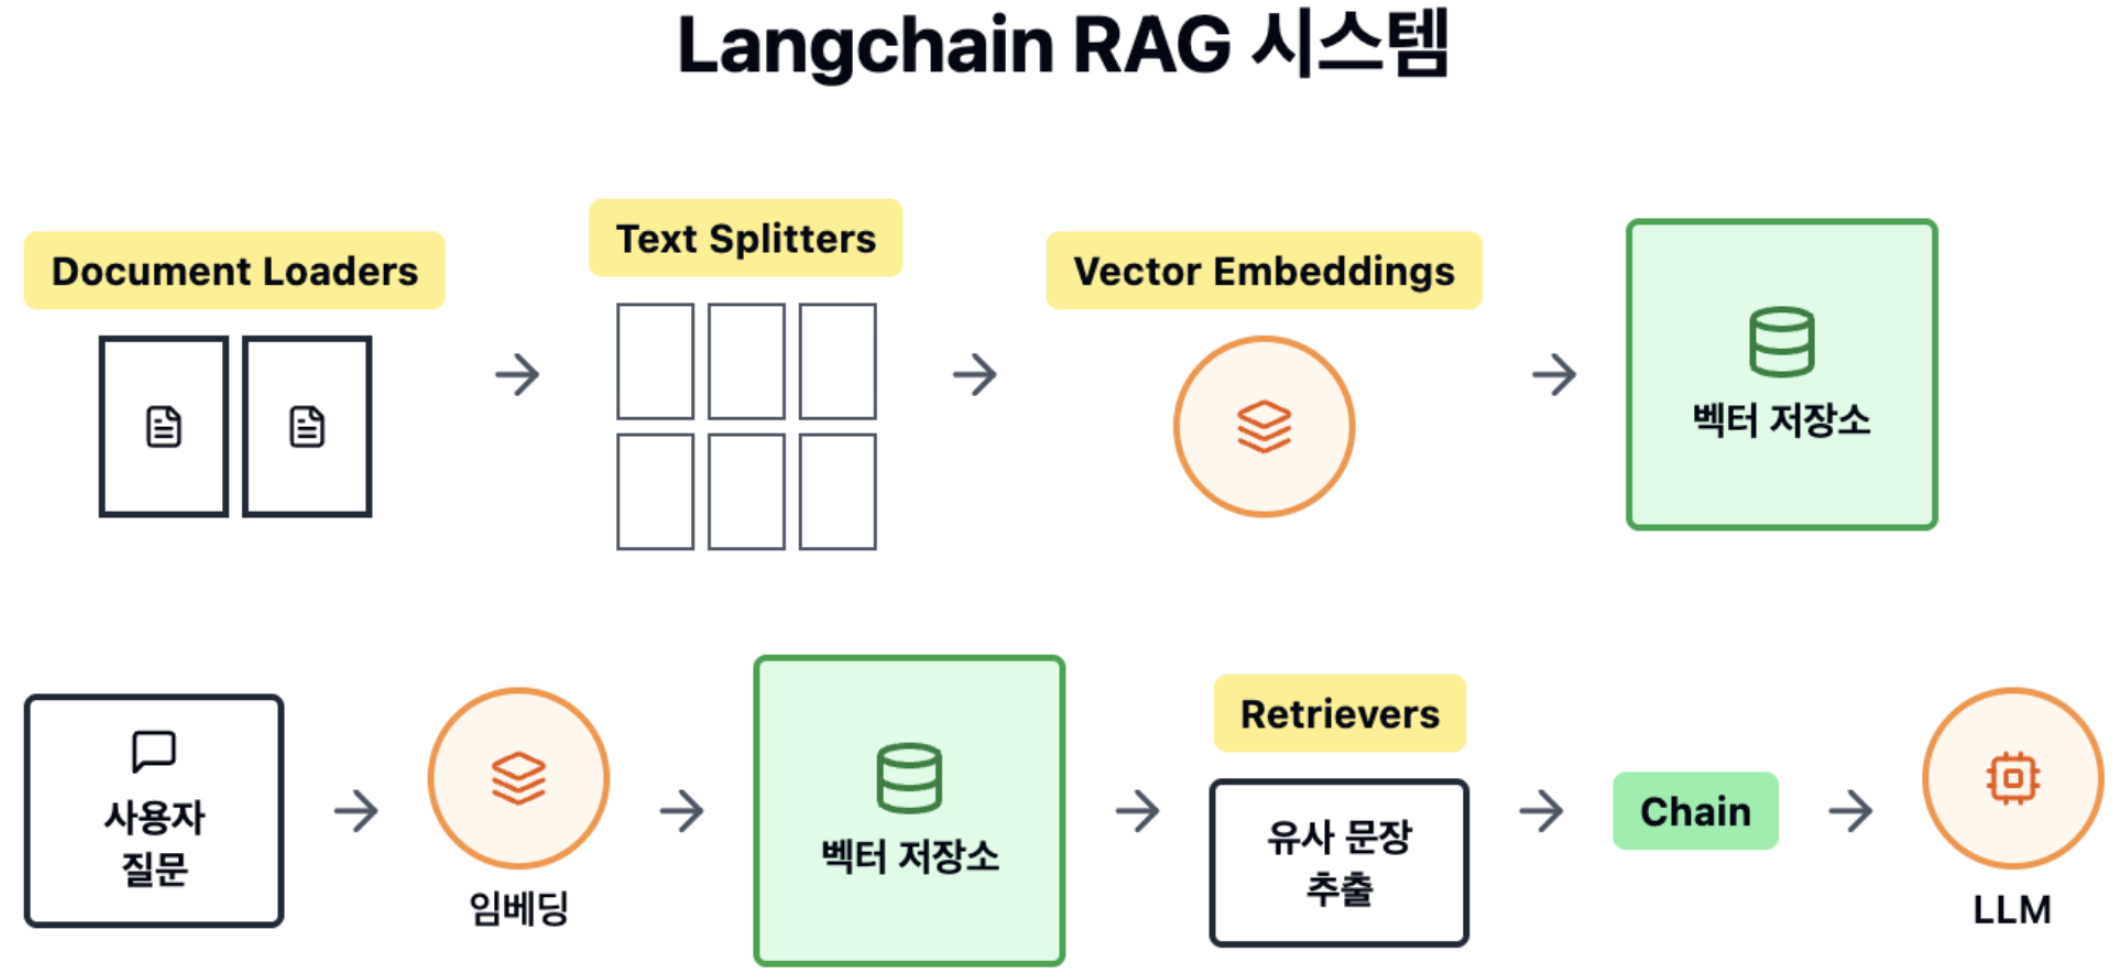

## 1. 데이터 로딩 및 전처리

먼저 `rag-keywords.txt` 파일을 로드하고 텍스트를 청크로 분할합니다.


### 데이터 로딩

In [1]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("data/rag-keywords.txt", encoding="utf-8")
documents = loader.load()

print(f"로드된 문서 수: {len(documents)}")


로드된 문서 수: 1


In [2]:
print(f"첫 번째 문서 길이: {len(documents[0].page_content)} 문자")
print("첫 번째 문서 내용 미리보기:")
print(documents[0].page_content[:500] + "...")

첫 번째 문서 길이: 5733 문자
첫 번째 문서 내용 미리보기:
Semantic Search

정의: 의미론적 검색은 사용자의 질의를 단순한 키워드 매칭을 넘어서 그 의미를 파악하여 관련된 결과를 반환하는 검색 방식입니다.
예시: 사용자가 "태양계 행성"이라고 검색하면, "목성", "화성" 등과 같이 관련된 행성에 대한 정보를 반환합니다.
연관키워드: 자연어 처리, 검색 알고리즘, 데이터 마이닝

Embedding

정의: 임베딩은 단어나 문장 같은 텍스트 데이터를 저차원의 연속적인 벡터로 변환하는 과정입니다. 이를 통해 컴퓨터가 텍스트를 이해하고 처리할 수 있게 합니다.
예시: "사과"라는 단어를 [0.65, -0.23, 0.17]과 같은 벡터로 표현합니다.
연관키워드: 자연어 처리, 벡터화, 딥러닝

Token

정의: 토큰은 텍스트를 더 작은 단위로 분할하는 것을 의미합니다. 이는 일반적으로 단어, 문장, 또는 구절일 수 있습니다.
예시: 문장 "나는 학교에 간다"를 "나는", "학교에", "간다"로 분할합니다.
연관키워드: 토큰화, 자연어...


### 텍스트 분할기 설정

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=250,      # 각 청크의 최대 크기
    chunk_overlap=50,    # 청크 간 겹치는 부분
    length_function=len,
    separators=["\n\n", "\n", " ", ""]
)

# 문서를 청크로 분할
texts = text_splitter.split_documents(documents)

print(f"분할된 청크 수: {len(texts)}")


분할된 청크 수: 30


In [4]:
print(f"첫 번째 청크 길이: {len(texts[0].page_content)} 문자")
print("첫 번째 청크 내용:")
print(texts[0].page_content)

첫 번째 청크 길이: 197 문자
첫 번째 청크 내용:
Semantic Search

정의: 의미론적 검색은 사용자의 질의를 단순한 키워드 매칭을 넘어서 그 의미를 파악하여 관련된 결과를 반환하는 검색 방식입니다.
예시: 사용자가 "태양계 행성"이라고 검색하면, "목성", "화성" 등과 같이 관련된 행성에 대한 정보를 반환합니다.
연관키워드: 자연어 처리, 검색 알고리즘, 데이터 마이닝

Embedding


## 2. 벡터 저장소 구축 (ChromaDB)

텍스트를 벡터로 변환하고 ChromaDB에 저장합니다.


### 임베딩 모델 설정

> 임베딩 모델 선언

In [5]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

### 벡터 저장소 생성

In [6]:
from langchain_community.vectorstores import Chroma

vectorstore = Chroma.from_documents(
    documents=texts,
    embedding=embeddings,
    collection_name="rag-keywords",
    persist_directory="./chroma_db"  # 벡터 저장소를 디스크에 저장
)

print("벡터 저장소 생성 완료!")
print(f"저장된 문서 수: {vectorstore._collection.count()}")


벡터 저장소 생성 완료!
저장된 문서 수: 30


## 3. 검색 테스트 

In [7]:
test_queries = [
    "LLM란 무엇인가요?",
    "벡터 데이터베이스의 역할은?",
    "임베딩은 어떻게 생성되나요?"
]

for query in test_queries:
    print(f"\n질문: {query}")
    results = vectorstore.similarity_search(
        query,  # 질문 
        k=1     # 유사한 데이터(청크) 조회할 횟수 
    )
    print(f"답변: {results[0].page_content[:150]}...")
    print("="*50)


질문: LLM란 무엇인가요?
답변: 정의: LLM은 대규모의 텍스트 데이터로 훈련된 큰 규모의 언어 모델을 의미합니다. 이러한 모델은 다양한 자연어 이해 및 생성 작업에 사용됩니다.
예시: OpenAI의 GPT 시리즈는 대표적인 대규모 언어 모델입니다.
연관키워드: 자연어 처리, 딥러닝, 텍스트 생성

...

질문: 벡터 데이터베이스의 역할은?
답변: VectorStore

정의: 벡터스토어는 벡터 형식으로 변환된 데이터를 저장하는 시스템입니다. 이는 검색, 분류 및 기타 데이터 분석 작업에 사용됩니다.
예시: 단어 임베딩 벡터들을 데이터베이스에 저장하여 빠르게 접근할 수 있습니다.
연관키워드: 임베딩, 데이터베이스...

질문: 임베딩은 어떻게 생성되나요?
답변: Embedding

정의: 임베딩은 단어나 문장 같은 텍스트 데이터를 저차원의 연속적인 벡터로 변환하는 과정입니다. 이를 통해 컴퓨터가 텍스트를 이해하고 처리할 수 있게 합니다.
예시: "사과"라는 단어를 [0.65, -0.23, 0.17]과 같은 벡터로 표현합니다.
...
